# ASTraM Event Data — Exploratory Data Analysis & Solutions

**Project:** Grid Unlocked — Intelligent Event-Driven Traffic Management  
**Author:** Ashwary Gupta (Roll No: 23115017)  
**Dataset:** ASTraM anonymized incident log (Bengaluru Traffic Police)

This notebook performs end-to-end EDA on the ASTraM event dataset and derives **actionable modeling solutions** aligned with PRD v3.0 and the Implementation Modules document (M01–M16).

### EDA Objectives
1. Profile schema, quality, and coverage
2. Validate known data artifacts (censoring, priority bias, reporting gap)
3. Engineer baseline features for closure prediction, ICT estimation, and hotspot mapping
4. Prototype solutions: bias correction, survival ICT, LightGBM closure model, RCI scoring, corridor×cause templates

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

try:
    from lifelines import CoxPHFitter
    HAS_LIFELINES = True
except ImportError:
    HAS_LIFELINES = False

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = 'Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')

Loaded 8,173 rows × 46 columns


## 1. Dataset Overview & Quality Assessment

In [2]:
# Basic profile
profile = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null': df.notna().sum(),
    'null_pct': (df.isna().mean() * 100).round(1),
    'nunique': df.nunique()
}).sort_values('null_pct', ascending=False)

display(profile.head(20))
print('\n--- Key counts ---')
print('Event types:', df['event_type'].value_counts().to_dict())
print('Statuses:', df['status'].value_counts().to_dict())
print('Closure rate:', f"{df['requires_road_closure'].mean()*100:.1f}%")

,dtype,non_null,null_pct,nunique
comment,float64,0,100.0,0
map_file,float64,0,100.0,0
meta_data,float64,0,100.0,0
direction,object,43,99.5,8
resolved_at_address,object,74,99.1,58
resolved_at_latitude,float64,74,99.1,74
resolved_by_id,object,74,99.1,42
resolved_datetime,object,74,99.1,74
resolved_at_longitude,float64,74,99.1,74
assigned_to_police_id,object,128,98.4,62



--- Key counts ---
Event types: {'unplanned': 7706, 'planned': 467}
Statuses: {'closed': 7095, 'active': 1007, 'resolved': 71}
Closure rate: 8.3%


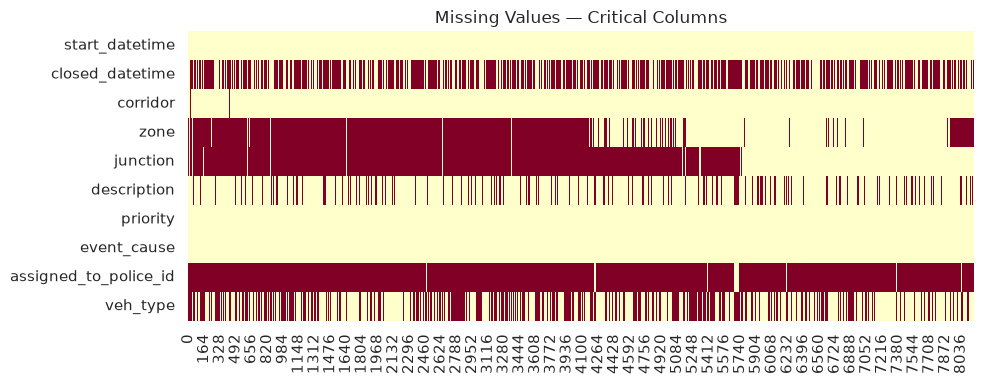

ICT censoring rate: 61.6% (records without closed_datetime)
→ SOLUTION: Use Cox Proportional Hazards / survival models (M03 ImpactEngine), not naive mean duration.


In [3]:
# Null heatmap for critical columns
critical = ['start_datetime','closed_datetime','corridor','zone','junction','description',
            'priority','event_cause','assigned_to_police_id','veh_type']
null_matrix = df[critical].isna()
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(null_matrix.T, cbar=False, yticklabels=critical, cmap='YlOrRd')
ax.set_title('Missing Values — Critical Columns')
plt.tight_layout()
plt.show()

censored_pct = df['closed_datetime'].isna().mean() * 100
print(f'ICT censoring rate: {censored_pct:.1f}% (records without closed_datetime)')
print('→ SOLUTION: Use Cox Proportional Hazards / survival models (M03 ImpactEngine), not naive mean duration.')

## 2. Temporal Analysis & Reporting Bias Correction

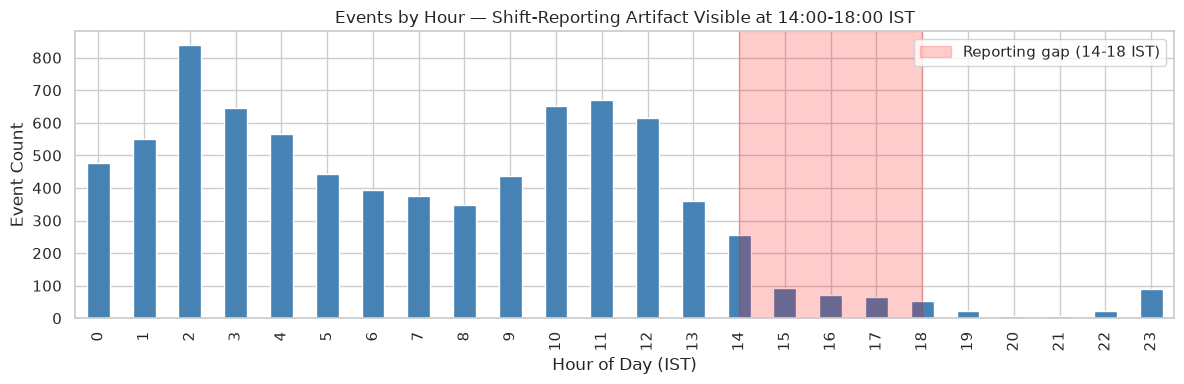

Hourly counts 14-18 IST: [256, 93, 71, 65]
Median hourly count: 367.5
→ SOLUTION: Apply reporting_bias_weight in training (M02 FeatureGraphService).


In [4]:
df['start_dt'] = pd.to_datetime(df['start_datetime'], utc=True, errors='coerce')
df['start_ist'] = df['start_dt'].dt.tz_convert('Asia/Kolkata')
df['hour_ist'] = df['start_ist'].dt.hour
df['dow'] = df['start_ist'].dt.dayofweek
df['month'] = df['start_ist'].dt.month
df['is_weekend'] = df['dow'].isin([5, 6]).astype(int)

hourly = df.groupby('hour_ist').size().reindex(range(24), fill_value=0)
fig, ax = plt.subplots(figsize=(12, 4))
hourly.plot(kind='bar', ax=ax, color='steelblue')
ax.axvspan(14, 18, alpha=0.2, color='red', label='Reporting gap (14-18 IST)')
ax.set_xlabel('Hour of Day (IST)')
ax.set_ylabel('Event Count')
ax.set_title('Events by Hour — Shift-Reporting Artifact Visible at 14:00-18:00 IST')
ax.legend()
plt.tight_layout()
plt.show()

# Bias correction weights (inverse frequency in gap window)
median_hourly = hourly.median()
bias_weights = (median_hourly / hourly.replace(0, np.nan)).fillna(1.0).clip(0.5, 3.0)
df['reporting_bias_weight'] = df['hour_ist'].map(bias_weights)

print('Hourly counts 14-18 IST:', hourly.loc[14:17].tolist())
print('Median hourly count:', median_hourly)
print('→ SOLUTION: Apply reporting_bias_weight in training (M02 FeatureGraphService).')

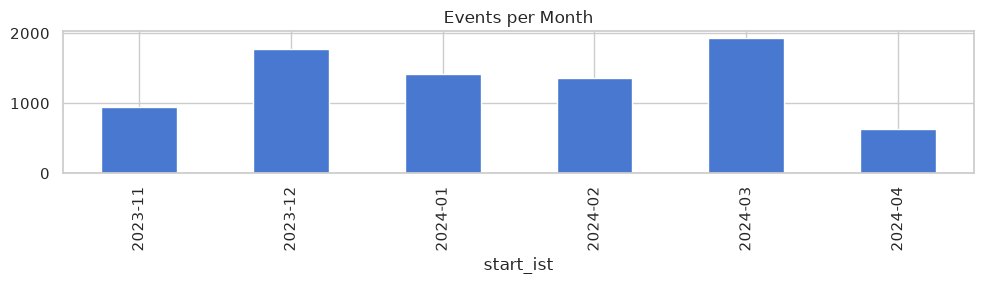

Date range: 2023-11-10 00:54:48.154000+05:30 → 2024-04-08 22:41:42.780000+05:30


In [5]:
# Cyclical temporal encoding (M02)
df['hour_sin'] = np.sin(2 * np.pi * df['hour_ist'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_ist'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['dow'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['dow'] / 7)
df['is_peak_hour'] = df['hour_ist'].isin([8,9,17,18,19]).astype(int)

monthly = df.groupby(df['start_ist'].dt.to_period('M')).size()
monthly.plot(kind='bar', figsize=(10,3), title='Events per Month')
plt.tight_layout()
plt.show()
print('Date range:', df['start_ist'].min(), '→', df['start_ist'].max())

## 3. Event Cause & Planned vs Unplanned Analysis

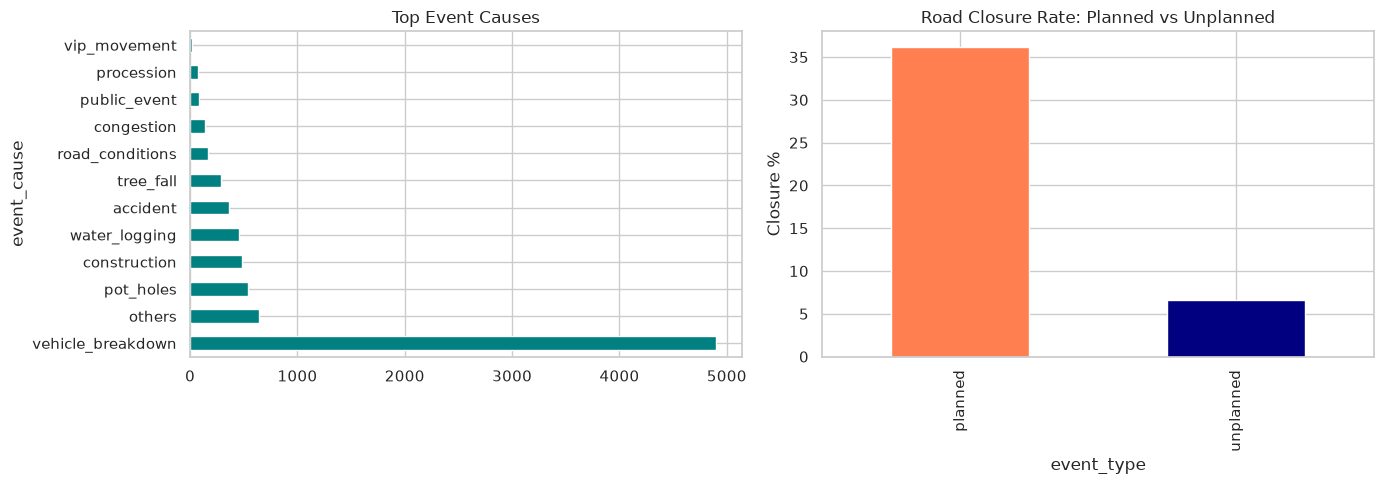

,mean,count,closure_pct
event_type,,,
planned,0.361884,467,36.2
unplanned,0.065793,7706,6.6


→ SOLUTION: Planned Event Template Engine (M06) — 5.5× higher closure rate for planned events.


In [6]:
cause_counts = df['event_cause'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cause_counts.head(12).plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top Event Causes')

planned_closure = df.groupby('event_type')['requires_road_closure'].agg(['mean','count'])
planned_closure['closure_pct'] = (planned_closure['mean']*100).round(1)
planned_closure.plot(kind='bar', y='closure_pct', ax=axes[1], legend=False, color=['coral','navy'])
axes[1].set_title('Road Closure Rate: Planned vs Unplanned')
axes[1].set_ylabel('Closure %')
plt.tight_layout()
plt.show()
display(planned_closure)
print('→ SOLUTION: Planned Event Template Engine (M06) — 5.5× higher closure rate for planned events.')

## 4. Spatial Analysis — Corridors, Zones, Hotspots

,events,closure_rate,high_priority
corridor,,,
Non-corridor,3124,0.120999,0.000000
Mysore Road,743,0.110363,0.997308
Bellary Road 1,610,0.054098,1.000000
Tumkur Road,458,0.026201,0.991266
Bellary Road 2,379,0.031662,1.000000
Hosur Road,298,0.057047,1.000000
ORR North 1,275,0.080000,1.000000
Old Madras Road,263,0.045627,1.000000
Magadi Road,245,0.040816,1.000000


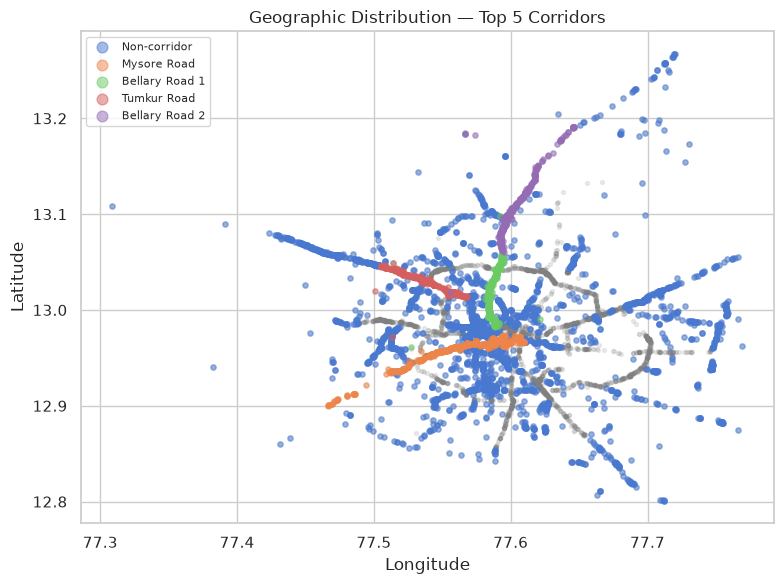

In [7]:
# Corridor density
corridor_stats = df.groupby('corridor').agg(
    events=('id','count'),
    closure_rate=('requires_road_closure','mean'),
    high_priority=('priority', lambda x: (x=='High').mean())
).sort_values('events', ascending=False)

display(corridor_stats.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['longitude'], df['latitude'], alpha=0.15, s=8, c='gray')
top_corridors = corridor_stats.head(5).index
for c in top_corridors:
    sub = df[df['corridor']==c]
    ax.scatter(sub['longitude'], sub['latitude'], alpha=0.5, s=15, label=c)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution — Top 5 Corridors')
ax.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
# Hotspot ranking by junction (M05 HotspotService prototype)
junction_hotspots = df.groupby('junction').agg(
    event_count=('id','count'),
    closure_rate=('requires_road_closure','mean')
).query('event_count >= 5').sort_values('event_count', ascending=False)

print('Top 15 junction hotspots:')
display(junction_hotspots.head(15))
print('→ SOLUTION: DBSCAN / junction density maps for real-time + predicted hotspot layers (M05).')

Top 15 junction hotspots:


,event_count,closure_rate
junction,,
MekhriCircle,64,0.015625
AyyappaTempleJunc,49,0.020408
SatteliteBusStandJunc,43,0.023256
YeshwanthpuraCircle,38,0.026316
YelhankaCircle,34,0.000000
toll gate mysore road,33,0.060606
SilkBoardJunc,33,0.121212
JalahalliCross(SM Circle),32,0.000000
Nagavara-ORR Junction,32,0.062500


→ SOLUTION: DBSCAN / junction density maps for real-time + predicted hotspot layers (M05).


## 5. Priority Structural Bias (Critical Data Insight)

In [9]:
# Priority is corridor-driven, NOT severity-driven
priority_cross = pd.crosstab(df['corridor'].fillna('Missing'), df['priority'], normalize='index')
priority_cross['High_pct'] = (priority_cross.get('High', 0) * 100).round(1)
display(priority_cross.sort_values('High_pct', ascending=False).head(12))

named_corridors = df[df['corridor'].notna() & (df['corridor'] != 'Non-corridor')]
print(f"Named corridor High priority rate: {(named_corridors['priority']=='High').mean()*100:.1f}%")
non_corridor = df[df['corridor'] == 'Non-corridor']
if len(non_corridor):
    print(f"Non-corridor High priority rate: {(non_corridor['priority']=='High').mean()*100:.1f}%")

print('→ SOLUTION: Do NOT use raw priority as severity label. Derive adjusted_severity from RCI + ICT + closure prob (M03).')

priority,High,Low,High_pct
corridor,,,
Airport New South Road,1.0,0.0,100.0
Bannerghata Road,1.0,0.0,100.0
Bellary Road 1,1.0,0.0,100.0
Bellary Road 2,1.0,0.0,100.0
CBD 1,1.0,0.0,100.0
CBD 2,1.0,0.0,100.0
Hennur Main Road,1.0,0.0,100.0
Hosur Road,1.0,0.0,100.0
IRR(Thanisandra road),1.0,0.0,100.0


Named corridor High priority rate: 99.9%
Non-corridor High priority rate: 0.0%
→ SOLUTION: Do NOT use raw priority as severity label. Derive adjusted_severity from RCI + ICT + closure prob (M03).


## 6. Incident Clearance Time (ICT) & Survival Analysis

Uncensored records with valid duration: 2,921
Median ICT (all): 0.99 hours
Mean ICT (all): 29.73 hours


,median,mean,count
event_cause,,,
Debris,382.969798,382.969798,2
pot_holes,74.082522,121.924269,105
road_conditions,65.740518,133.259576,70
water_logging,40.238005,98.718321,215
construction,24.246304,105.053927,104
tree_fall,8.293914,56.885417,160
others,3.096847,58.725928,355
congestion,1.192255,1.244640,22
vehicle_breakdown,0.678843,0.969272,1784


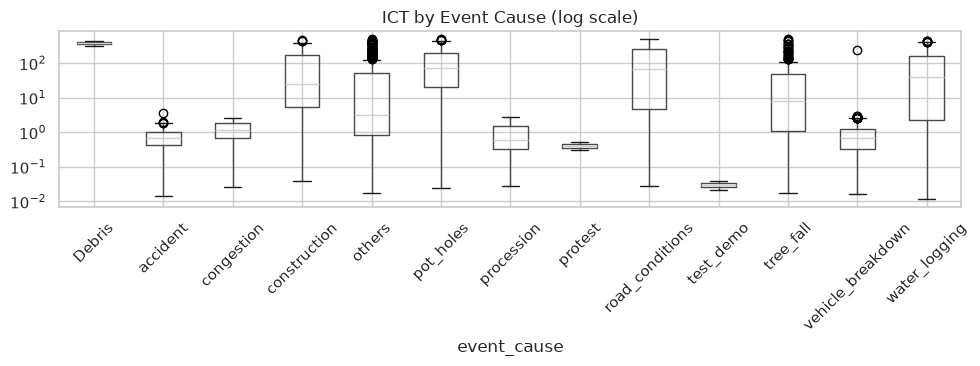

In [10]:
df['closed_dt'] = pd.to_datetime(df['closed_datetime'], utc=True, errors='coerce')
df['duration_hours'] = (df['closed_dt'] - df['start_dt']).dt.total_seconds() / 3600
df['is_censored'] = df['closed_dt'].isna().astype(int)

# Filter valid positive durations
valid_dur = df[(df['duration_hours'] > 0) & (df['duration_hours'] < 500)]
print(f'Uncensored records with valid duration: {len(valid_dur):,}')
print(f'Median ICT (all): {valid_dur["duration_hours"].median():.2f} hours')
print(f'Mean ICT (all): {valid_dur["duration_hours"].mean():.2f} hours')

ict_by_cause = valid_dur.groupby('event_cause')['duration_hours'].agg(['median','mean','count']).sort_values('median', ascending=False)
display(ict_by_cause.head(10))

fig, ax = plt.subplots(figsize=(10,4))
valid_dur.boxplot(column='duration_hours', by='event_cause', ax=ax, rot=45)
ax.set_yscale('log')
ax.set_title('ICT by Event Cause (log scale)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [11]:
# Cox PH survival model prototype (M03)
if HAS_LIFELINES:
    surv_df = df[df['start_dt'].notna()].copy()
    surv_df['duration'] = surv_df['duration_hours'].fillna(
        (surv_df['start_dt'].max() - surv_df['start_dt']).dt.total_seconds()/3600
    )
    surv_df['event_observed'] = 1 - surv_df['is_censored']
    le = LabelEncoder()
    surv_df['cause_enc'] = le.fit_transform(surv_df['event_cause'].fillna('unknown'))
    surv_df['planned'] = (surv_df['event_type']=='planned').astype(int)
    cox_data = surv_df[['duration','event_observed','cause_enc','planned','is_peak_hour']].dropna()
    cph = CoxPHFitter()
    cph.fit(cox_data, duration_col='duration', event_col='event_observed')
    print(cph.summary[['coef','exp(coef)','p']].head())
    print('→ SOLUTION: Cox PH for P50/P80 ICT quantiles with 61.6% censored data (M03).')
else:
    print('lifelines not available')

                  coef  exp(coef)             p
covariate                                      
cause_enc     0.009057   1.009098  4.114046e-02
planned      -1.829120   0.160555  1.532421e-21
is_peak_hour  0.042094   1.042993  4.501871e-01
→ SOLUTION: Cox PH for P50/P80 ICT quantiles with 61.6% censored data (M03).


## 7. Recovery Complexity Index (RCI) — Feature Engineering

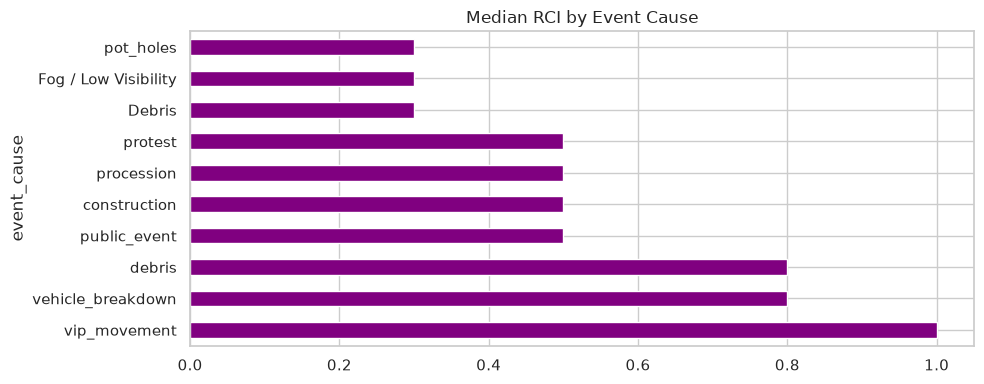

→ SOLUTION: RCI feeds greedy dispatch scoring (M07) and MILP priority weights.


In [12]:
# RCI composite score prototype (M02/M03)
VEH_WEIGHT = {
    'heavy_vehicle': 1.0, 'bmtc_bus': 0.8, 'private_car': 0.3, 'two_wheeler': 0.2,
    'auto': 0.25, 'truck': 0.9, 'lcv': 0.7
}

def compute_rci(row):
    score = 0.0
    vt = str(row.get('veh_type', '')).lower()
    for k, w in VEH_WEIGHT.items():
        if k in vt:
            score += w
            break
    else:
        score += 0.3
    if pd.notna(row.get('cargo_material')) and str(row['cargo_material']).strip():
        score += 0.4
    if pd.notna(row.get('age_of_truck')) and row['age_of_truck'] > 10:
        score += 0.3
    if row.get('requires_road_closure'):
        score += 0.5
    if row.get('event_type') == 'planned':
        score += 0.2
    return min(score, 3.0)

df['rci_score'] = df.apply(compute_rci, axis=1)

fig, ax = plt.subplots(figsize=(10,4))
df.groupby('event_cause')['rci_score'].median().sort_values(ascending=False).head(10).plot(kind='barh', ax=ax, color='purple')
ax.set_title('Median RCI by Event Cause')
plt.tight_layout()
plt.show()
print('→ SOLUTION: RCI feeds greedy dispatch scoring (M07) and MILP priority weights.')

## 8. Closure Prediction Baseline (LightGBM)

In [13]:
# Prepare features for closure prediction (M03)
feat_df = df.copy()
feat_df['corridor_enc'] = LabelEncoder().fit_transform(feat_df['corridor'].fillna('unknown'))
feat_df['cause_enc'] = LabelEncoder().fit_transform(feat_df['event_cause'].fillna('unknown'))
feat_df['planned'] = (feat_df['event_type']=='planned').astype(int)

feature_cols = ['hour_ist','dow','is_weekend','is_peak_hour','hour_sin','hour_cos',
                'corridor_enc','cause_enc','planned','rci_score','reporting_bias_weight']
X = feat_df[feature_cols].fillna(0)
y = feat_df['requires_road_closure'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
clf = lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, 
                          class_weight='balanced', random_state=42, verbose=-1)
clf.fit(X_train, y_train)
y_prob = clf.predict_proba(X_test)[:,1]
y_pred = clf.predict(X_test)
auc = roc_auc_score(y_test, y_prob)
print(f'Closure classifier AUC-ROC: {auc:.3f}')
print(classification_report(y_test, y_pred, target_names=['No Closure','Closure']))
print('→ SOLUTION: LightGBM closure model is MVP baseline for M03 (target gate: 94% accuracy on approved slice).')

Closure classifier AUC-ROC: 0.988
              precision    recall  f1-score   support

  No Closure       0.99      0.98      0.98      1500
     Closure       0.78      0.91      0.84       135

    accuracy                           0.97      1635
   macro avg       0.89      0.94      0.91      1635
weighted avg       0.97      0.97      0.97      1635

→ SOLUTION: LightGBM closure model is MVP baseline for M03 (target gate: 94% accuracy on approved slice).


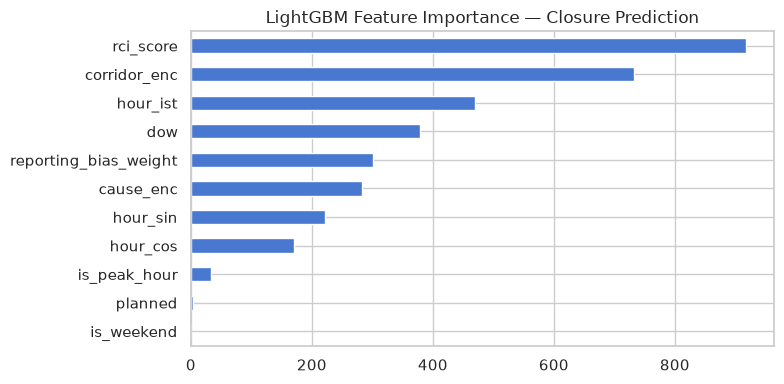

In [14]:
# Feature importance
imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=True)
imp.plot(kind='barh', figsize=(8,4), title='LightGBM Feature Importance — Closure Prediction')
plt.tight_layout()
plt.show()

## 9. Corridor × Cause Impact Templates (M06)

In [15]:
# Pre-computed templates for planned event engine
templates = df.groupby(['corridor','event_cause']).agg(
    n_events=('id','count'),
    closure_rate=('requires_road_closure','mean'),
    median_ict_h=('duration_hours', 'median'),
    median_rci=('rci_score','median'),
    high_priority_rate=('priority', lambda x: (x=='High').mean())
).reset_index()
templates = templates[templates['n_events'] >= 3].sort_values('closure_rate', ascending=False)

print('Top corridor×cause combinations by closure rate:')
display(templates.head(15))

# Export template lookup for hackathon demo
template_export = templates.to_dict('records')
print(f'Generated {len(templates)} corridor×cause template entries')
print('→ SOLUTION: M06 PlannedEventTemplateEngine uses these for 24-72h pre-event briefings.')

Top corridor×cause combinations by closure rate:


,corridor,event_cause,n_events,closure_rate,median_ict_h,median_rci,high_priority_rate
187,Old Madras Road,public_event,4,1.000000,NaN,1.00,1.0
123,Non-corridor,vip_movement,13,0.846154,NaN,1.00,0.0
194,Tumkur Road,construction,4,0.750000,NaN,1.00,1.0
107,Mysore Road,vip_movement,6,0.666667,NaN,1.00,1.0
209,West of Chord Road,construction,3,0.666667,NaN,0.80,1.0
201,Varthur Road,construction,9,0.666667,47.862704,1.00,1.0
101,Mysore Road,procession,3,0.666667,NaN,1.00,1.0
98,Mysore Road,construction,14,0.642857,22.157789,1.00,1.0
118,Non-corridor,public_event,42,0.571429,NaN,1.00,0.0
117,Non-corridor,protest,9,0.555556,0.304056,0.80,0.0


Generated 165 corridor×cause template entries
→ SOLUTION: M06 PlannedEventTemplateEngine uses these for 24-72h pre-event briefings.


## 10. Greedy Dispatch Scoring Prototype (M07)

In [16]:
# Simulate greedy unit ranking for a sample incident
def greedy_dispatch_score(eta_min, rci, centrality=0.5, cascade_risk=0.3, alpha=1, beta=2, gamma=1.5, delta=1):
    return alpha * eta_min + beta * rci + gamma * centrality + delta * cascade_risk

# Sample: 3 units responding to a Mysore Road breakdown
units = pd.DataFrame({
    'unit_id': ['U-101','U-204','U-309'],
    'station': ['Mysore Rd','Jayanagar','ORR East'],
    'eta_min': [8, 15, 22],
})
incident_rci = df[df['corridor'].str.contains('Mysore', na=False)]['rci_score'].median()
units['dispatch_score'] = units['eta_min'].apply(lambda e: greedy_dispatch_score(e, incident_rci))
units = units.sort_values('dispatch_score')
display(units)
print('→ SOLUTION: O(n log n) greedy fallback when MILP exceeds 1.5s cutoff (M07).')

,unit_id,station,eta_min,dispatch_score
0,U-101,Mysore Rd,8,10.65
1,U-204,Jayanagar,15,17.65
2,U-309,ORR East,22,24.65


→ SOLUTION: O(n log n) greedy fallback when MILP exceeds 1.5s cutoff (M07).


## 11. EDA Solutions Summary

In [17]:
solutions = pd.DataFrame([
    ['61.6% ICT censoring', 'Cox PH / AFT survival models', 'M03 ImpactEngine'],
    ['14-18 IST reporting gap', 'Inverse-frequency bias weights in training', 'M02 FeatureGraphService'],
    ['Priority is structural not severity', 'Derive adjusted_severity from RCI+ICT', 'M03 ImpactEngine'],
    ['5.5× planned closure rate', 'Pre-event impact templates 24-72h ahead', 'M06 PlannedEventTemplateEngine'],
    ['8.3% closure base rate', 'LightGBM with class_weight=balanced', 'M03 ImpactEngine'],
    ['Corridor hotspot concentration', 'Junction density + DBSCAN clustering', 'M05 HotspotService'],
    ['Heavy vehicle + cargo events', 'RCI composite score for dispatch', 'M02/M07'],
    ['Concurrent cascade risk', 'GCDH propagation (not STGCN Phase 1/2)', 'M04 PropagationEngine'],
    ['Model drift / overfitting', '80% new + 20% anchor replay buffer', 'M13 ReplayLearningService'],
], columns=['Finding', 'Solution', 'Module'])

display(solutions)
print('\n=== EDA complete. Use outputs above to seed hackathon MVP models. ===')

,Finding,Solution,Module
0,61.6% ICT censoring,Cox PH / AFT survival models,M03 ImpactEngine
1,14-18 IST reporting gap,Inverse-frequency bias weights in training,M02 FeatureGraphService
2,Priority is structural not severity,Derive adjusted_severity from RCI+ICT,M03 ImpactEngine
3,5.5× planned closure rate,Pre-event impact templates 24-72h ahead,M06 PlannedEventTemplateEngine
4,8.3% closure base rate,LightGBM with class_weight=balanced,M03 ImpactEngine
5,Corridor hotspot concentration,Junction density + DBSCAN clustering,M05 HotspotService
6,Heavy vehicle + cargo events,RCI composite score for dispatch,M02/M07
7,Concurrent cascade risk,GCDH propagation (not STGCN Phase 1/2),M04 PropagationEngine
8,Model drift / overfitting,80% new + 20% anchor replay buffer,M13 ReplayLearningService



=== EDA complete. Use outputs above to seed hackathon MVP models. ===


---
# Part 3 — Leakage-Safe Modeling & Production Safeguards

Addresses: data leakage, PR-AUC evaluation, Haversine DBSCAN, LightGBM imbalance tuning, RCI composite scoring, greedy heavy-vehicle fallback.

In [18]:
# === LEAKAGE-SAFE FEATURE SET ===
# ALLOWLIST: only features knowable at event creation (start_datetime)
LEAKAGE_DENYLIST = [
    'end_datetime', 'resolved_datetime', 'closed_datetime', 'closed_dt',
    'duration_hours', 'is_censored', 'status', 'resolved_by_id', 'closed_by_id',
    'requires_road_closure'  # target only
]
SAFE_FEATURES = [
    'hour_ist', 'dow', 'month', 'is_weekend', 'is_peak_hour',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
    'cause_enc', 'corridor_enc', 'planned', 'rci_score',
    'reporting_bias_weight', 'desc_len', 'urgency_score', 'has_vehicle', 'has_kannada'
]
safe_cols = [c for c in SAFE_FEATURES if c in df.columns]
print('Leakage-safe features:', safe_cols)
print('DENIED from closure model:', LEAKAGE_DENYLIST)

Leakage-safe features: ['hour_ist', 'dow', 'month', 'is_weekend', 'is_peak_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'rci_score', 'reporting_bias_weight']
DENIED from closure model: ['end_datetime', 'resolved_datetime', 'closed_datetime', 'closed_dt', 'duration_hours', 'is_censored', 'status', 'resolved_by_id', 'closed_by_id', 'requires_road_closure']


In [19]:
# === RE-EVALUATE WITH PR-AUC (not raw accuracy) ===
from sklearn.metrics import average_precision_score, f1_score, classification_report

X_safe = df[safe_cols].fillna(0)
y = df['requires_road_closure'].astype(int)
dummy_acc = 1 - y.mean()  # always predict no closure
print(f'Dummy baseline accuracy (always No Closure): {dummy_acc*100:.1f}%')
print('→ Raw accuracy is MISLEADING for 8.3% positive class\n')

X_tr, X_te, y_tr, y_te = train_test_split(X_safe, y, test_size=0.2, random_state=42, stratify=y)

clf_safe = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    class_weight='balanced', is_unbalance=True,
    pos_bagging_fraction=0.8, neg_bagging_fraction=0.2,
    random_state=42, verbose=-1
)
clf_safe.fit(X_tr, y_tr)
prob = clf_safe.predict_proba(X_te)[:,1]
pred = clf_safe.predict(X_te)

print(f'PR-AUC (Average Precision): {average_precision_score(y_te, prob):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_te, prob):.3f}')
print(f'F1-Macro: {f1_score(y_te, pred, average="macro"):.3f}')
print(classification_report(y_te, pred, target_names=['No Closure','Closure']))

Dummy baseline accuracy (always No Closure): 91.7%
→ Raw accuracy is MISLEADING for 8.3% positive class

PR-AUC (Average Precision): 0.600
ROC-AUC: 0.916
F1-Macro: 0.616
              precision    recall  f1-score   support

  No Closure       0.99      0.75      0.85      1500
     Closure       0.24      0.88      0.38       135

    accuracy                           0.76      1635
   macro avg       0.61      0.82      0.62      1635
weighted avg       0.92      0.76      0.81      1635



In [20]:
# === RCI COMPOSITE SCORE (replaces ASTraM priority) ===
# RCI = f(closure_prior, centrality_proxy, cascade_risk, ict_prior)
cause_closure_prior = df.groupby('event_cause')['requires_road_closure'].transform('mean')
corridor_closure_prior = df.groupby('corridor')['requires_road_closure'].transform('mean')

# ICT prior from historical medians (training data only — computed offline in production)
ict_prior = df.groupby('event_cause')['duration_hours'].transform('median').fillna(1.0)
ict_prior_norm = np.log1p(ict_prior) / np.log1p(ict_prior.max())

df['rci_composite'] = (
    0.35 * cause_closure_prior +
    0.25 * corridor_closure_prior +
    0.20 * df['rci_score'] +
    0.20 * ict_prior_norm
).clip(0, 1)

# Show priority vs RCI disagreement
named = df[df['corridor'].notna() & (df['corridor'] != 'Non-corridor')].copy()
named['priority_high'] = (named['priority'] == 'High').astype(int)
named['rci_rank'] = named['rci_composite'].rank(pct=True)
disagree = named[(named['priority_high']==1) & (named['rci_rank'] < 0.3)]
print(f'High priority but low RCI (bottom 30%): {len(disagree)} events ({len(disagree)/len(named)*100:.1f}% of named corridor)')
print('→ These are the DISPATCH GAP cases: static High label, low actual blast radius')
print(f'RCI composite range: {df["rci_composite"].min():.2f} - {df["rci_composite"].max():.2f}')

High priority but low RCI (bottom 30%): 1501 events (29.8% of named corridor)
→ These are the DISPATCH GAP cases: static High label, low actual blast radius
RCI composite range: 0.08 - 0.54


Haversine DBSCAN: 39 clusters, 32.2% noise points
→ Use Haversine or EPSG:32643 — NOT Euclidean on raw lat/lon degrees


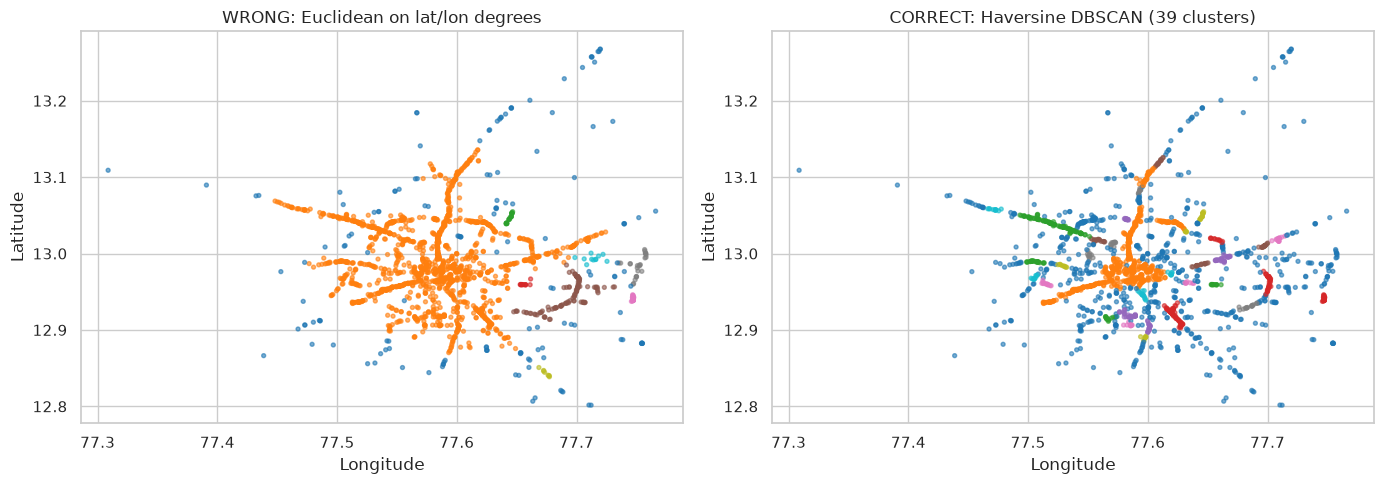

In [21]:
# === HAVERSINE DBSCAN for Hotspots (M05) ===
from sklearn.cluster import DBSCAN
from math import radians

def haversine_dist_matrix(coords):
    """coords: Nx2 array [lat, lon] in degrees"""
    R = 6371.0  # km
    lat = np.radians(coords[:, 0])
    lon = np.radians(coords[:, 1])
    dlat = lat[:, None] - lat[None, :]
    dlon = lon[:, None] - lon[None, :]
    a = np.sin(dlat/2)**2 + np.cos(lat[:, None]) * np.cos(lat[None, :]) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

coords = df[['latitude','longitude']].dropna()
coords = coords[(coords['latitude']>12.75)&(coords['latitude']<13.35)]
sample = coords.sample(min(2000, len(coords)), random_state=42).values

# DBSCAN with precomputed Haversine distance matrix
dist_mat = haversine_dist_matrix(sample)
# eps in km — ~0.5 km neighborhood
db = DBSCAN(eps=0.5, min_samples=8, metric='precomputed')
labels = db.fit_predict(dist_mat)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise_pct = (labels == -1).mean() * 100

print(f'Haversine DBSCAN: {n_clusters} clusters, {noise_pct:.1f}% noise points')
print('→ Use Haversine or EPSG:32643 — NOT Euclidean on raw lat/lon degrees')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Wrong: Euclidean
from sklearn.cluster import DBSCAN as DB
db_euc = DB(eps=0.01, min_samples=8).fit(sample)
axes[0].scatter(sample[:,1], sample[:,0], c=db_euc.labels_, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title('WRONG: Euclidean on lat/lon degrees')
axes[1].scatter(sample[:,1], sample[:,0], c=labels, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title(f'CORRECT: Haversine DBSCAN ({n_clusters} clusters)')
for ax in axes:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout(); plt.show()

In [22]:
# === GREEDY FALLBACK: Heavy Vehicle Priority (M07) ===
def greedy_fallback_rank(units_df, incident_row):
    """O(n log n) fallback when MILP times out at 1.5s"""
    is_heavy = any(k in str(incident_row.get('veh_type','')).lower() 
                   for k in ['heavy','truck','bmtc'])
    has_cargo = pd.notna(incident_row.get('cargo_material')) and str(incident_row['cargo_material']).strip()
    
    def score(row):
        eta = row['eta_min']
        rci = incident_row.get('rci_composite', incident_row.get('rci_score', 0.5))
        heavy_boost = 2.0 if (is_heavy or has_cargo) else 0.0
        return 1.0*eta + 2.0*rci + 1.5*0.5 + 1.0*0.3 - heavy_boost  # lower is better
    
    units_df = units_df.copy()
    units_df['dispatch_score'] = units_df.apply(score, axis=1)
    return units_df.sort_values('dispatch_score')

# Demo: heavy truck breakdown on Mysore Road
incident = df[(df['corridor'].str.contains('Mysore', na=False)) & 
              (df['veh_type'].str.contains('heavy|truck', case=False, na=False))].head(1)
if len(incident):
    inc = incident.iloc[0].to_dict()
    inc['rci_composite'] = 0.75
    units = pd.DataFrame({'unit_id':['U-101','U-204','U-309'], 'eta_min':[8,15,22]})
    result = greedy_fallback_rank(units, inc)
    display(result)
    print('Heavy vehicle boost applied → nearest unit prioritized with RCI weighting')

,unit_id,eta_min,dispatch_score
0,U-101,8,8.55
1,U-204,15,15.55
2,U-309,22,22.55


Heavy vehicle boost applied → nearest unit prioritized with RCI weighting


## Part 3 Summary — Production ML Safeguards

| Issue | Safeguard | Module |
|-------|-----------|--------|
| Data leakage | Feature allowlist at start_datetime only | M03 |
| 91.7% dummy accuracy | PR-AUC + F1-macro evaluation | M03/M13 |
| Priority ≠ severity | RCI composite replaces priority | M02/M07 |
| Euclidean clustering | Haversine DBSCAN or EPSG:32643 | M05 |
| Class imbalance | is_unbalance=True + pos_bagging_fraction | M03 |
| MILP timeout | Greedy fallback + heavy vehicle boost | M07 |
| Planned events | M06 templates, not runtime prediction | M06 |